# OIBSIP — Task 5: Sales Prediction Using Python

### Objective
Predict product sales from **TV, Radio, and Newspaper advertising budgets** using regression models.

**Workflow:** Data Loading → EDA → Visualization → Cleaning → Outlier Removal → Feature Selection → Train/Test Split → Model Training → Evaluation → Residual Analysis → Feature Impact → Best Model → Final Prediction

## 1. Import Libraries
Only the libraries required for this project are imported.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load Dataset
Keep `Advertising_Budget_and_Sales.csv` in the same folder as this notebook.

In [ ]:
df = pd.read_csv("/Users/sakshamchauhan/Downloads/Github/OIBSIP/OIBSIP-DataScience-Task5-Sales_Prediction/Advertising_Budget_and_Sales.csv")
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## 3. Understand the Dataset
Check the size, columns, data types, missing values, duplicates, and basic statistics.

In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

df.describe()

Shape: (200, 5)

Columns: ['Unnamed: 0', 'TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)', 'Sales ($)']

Data Types:
Unnamed: 0                   int64
TV Ad Budget ($)           float64
Radio Ad Budget ($)        float64
Newspaper Ad Budget ($)    float64
Sales ($)                  float64
dtype: object

Missing Values:
Unnamed: 0                 0
TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales ($)                  0
dtype: int64

Duplicate Rows: 0


,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


## 4. Data Cleaning & Preparation
The `Unnamed: 0` column is only an index/record identifier, so it has no predictive value and is removed.
Column names are simplified to make the later code easier to read.

In [4]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df = df.rename(columns={
    "TV Ad Budget ($)": "TV",
    "Radio Ad Budget ($)": "Radio",
    "Newspaper Ad Budget ($)": "Newspaper",
    "Sales ($)": "Sales"
})

df = df.drop_duplicates()
df = df.dropna()

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## 5. Exploratory Data Analysis
Look at the distribution and relationship of the advertising channels with sales.

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


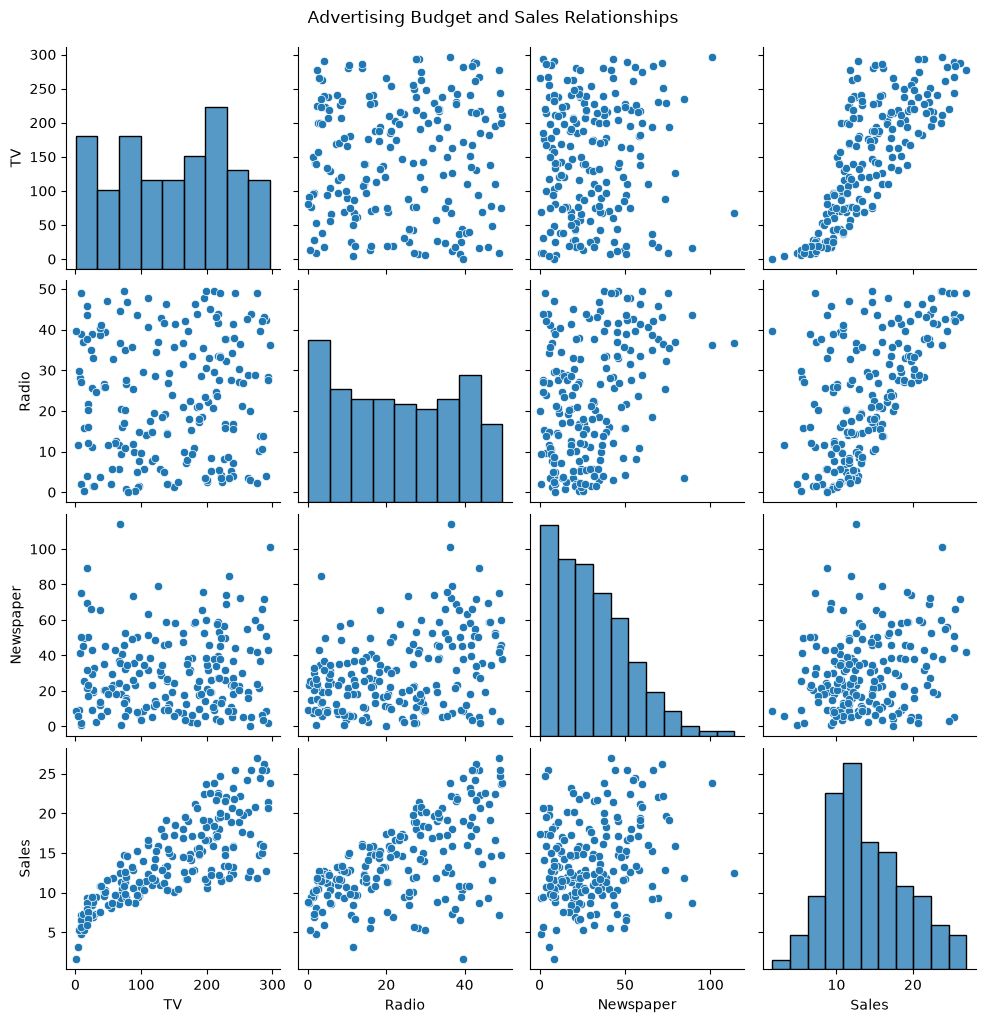

In [5]:
display(df.describe())

sns.pairplot(df, diag_kind="hist")
plt.suptitle("Advertising Budget and Sales Relationships", y=1.02)
plt.show()

## 6. Individual Relationships with Sales
These scatter plots show how each advertising channel relates to sales.

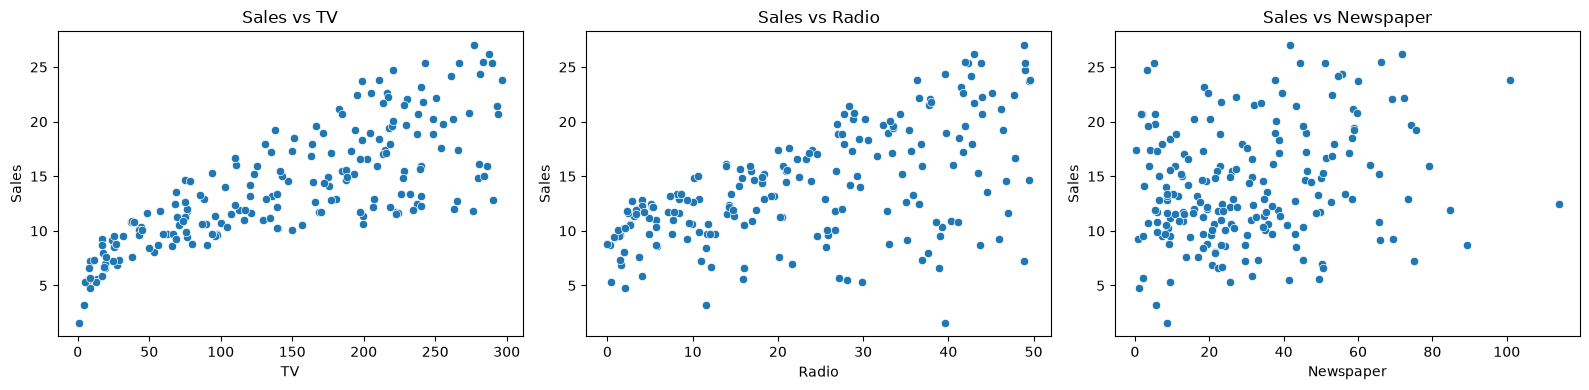

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, feature in zip(axes, ["TV", "Radio", "Newspaper"]):
    sns.scatterplot(data=df, x=feature, y="Sales", ax=ax)
    ax.set_title(f"Sales vs {feature}")

plt.tight_layout()
plt.show()

## 7. Correlation Analysis
Correlation helps us understand the linear relationship between each numerical variable and sales.

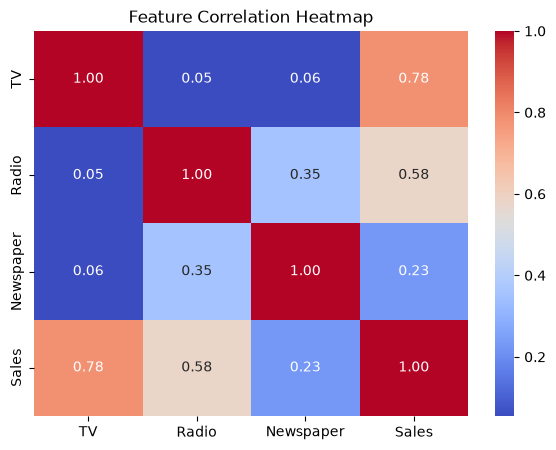

Correlation with Sales:


Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64

In [7]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

print("Correlation with Sales:")
display(correlation["Sales"].sort_values(ascending=False))

## 8. Outlier Detection & Removal
Extreme values can strongly affect regression models. We use the **IQR method** to remove unusually extreme observations.

This is done before modeling so the models are trained on a cleaner dataset.

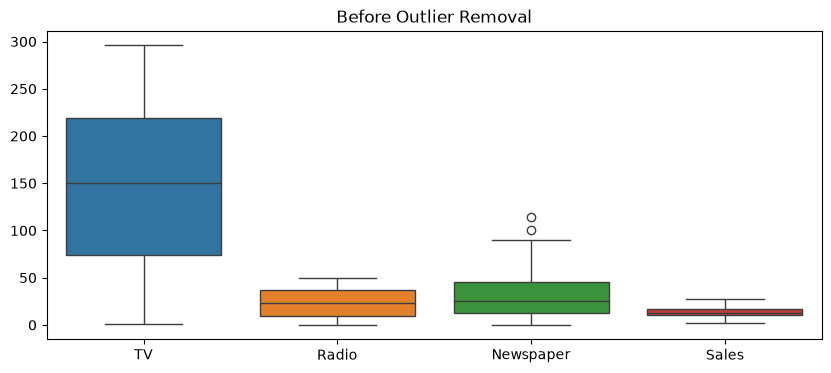

Rows before: 200
Rows after : 198
Rows removed: 2


In [8]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df[["TV", "Radio", "Newspaper", "Sales"]])
plt.title("Before Outlier Removal")
plt.show()

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[~((df < lower) | (df > upper)).any(axis=1)].copy()

print("Rows before:", len(df))
print("Rows after :", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

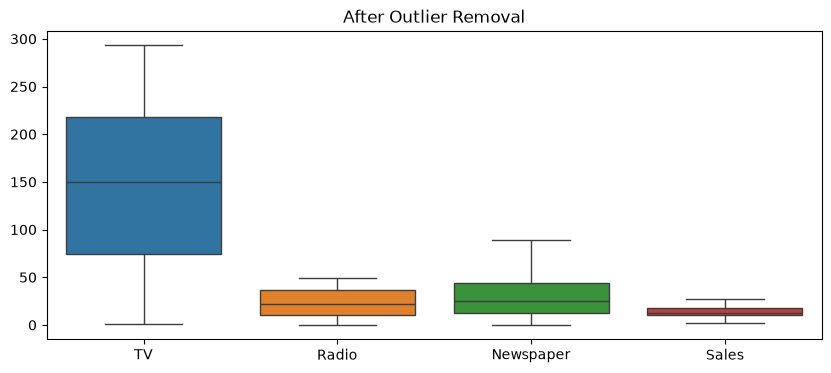

In [9]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_clean[["TV", "Radio", "Newspaper", "Sales"]])
plt.title("After Outlier Removal")
plt.show()

## 9. Feature Selection
The record ID has already been removed because it is not a predictive feature.

We retain advertising features whose absolute correlation with Sales is meaningful. The final selected features are determined from the correlation analysis rather than removing a useful feature just to improve the score.

In [10]:
target = "Sales"

feature_correlations = df_clean.corr(numeric_only=True)["Sales"].drop("Sales").abs()
selected_features = feature_correlations[feature_correlations >= 0.10].index.tolist()

print("Feature correlations:")
display(feature_correlations.sort_values(ascending=False))

print("Selected Features:", selected_features)

Feature correlations:


TV           0.779121
Radio        0.576748
Newspaper    0.219555
Name: Sales, dtype: float64

Selected Features: ['TV', 'Radio', 'Newspaper']


## 10. Train-Test Split
Use 80% of the cleaned data for training and 20% for testing.

In [11]:
X = df_clean[selected_features]
y = df_clean["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 158
Testing samples : 40


## 11. Model Training
Three models are used:

- **Linear Regression** — simple baseline.
- **Ridge Regression** — adds L2 regularization to reduce overfitting.
- **Random Forest Regressor** — captures non-linear relationships.

In [12]:
linear_model = LinearRegression()

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

random_forest_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

## 12. Model Evaluation
We compare models using **MAE, RMSE, and R²**.

- Lower MAE is better.
- Lower RMSE is better.
- Higher R² is better.

In [13]:
models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Random Forest": random_forest_model
}

results = []

for name, model in models.items():
    predictions = model.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R2 Score": r2_score(y_test, predictions)
    })

results = pd.DataFrame(results).sort_values("R2 Score", ascending=False)
display(results.round(4))

,Model,MAE,RMSE,R2 Score
2,Random Forest,0.5370,0.6439,0.9847
0,Linear Regression,1.2497,1.6556,0.8989
1,Ridge Regression,1.2565,1.6634,0.8980


## 13. Model Comparison
R² provides an easy way to compare how much variation in Sales is explained by each model.

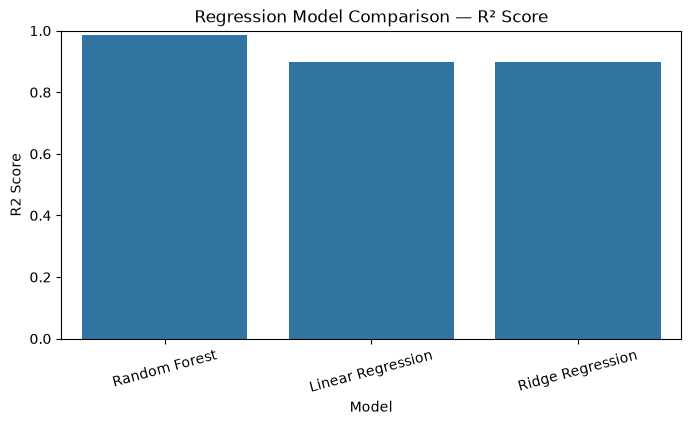

In [14]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results, x="Model", y="R2 Score")
plt.ylim(0, 1)
plt.title("Regression Model Comparison — R² Score")
plt.xticks(rotation=15)
plt.show()

## 14. Residual Analysis — Best Model
Residuals are the differences between actual and predicted sales. A good model should have residuals scattered around zero without a strong pattern.

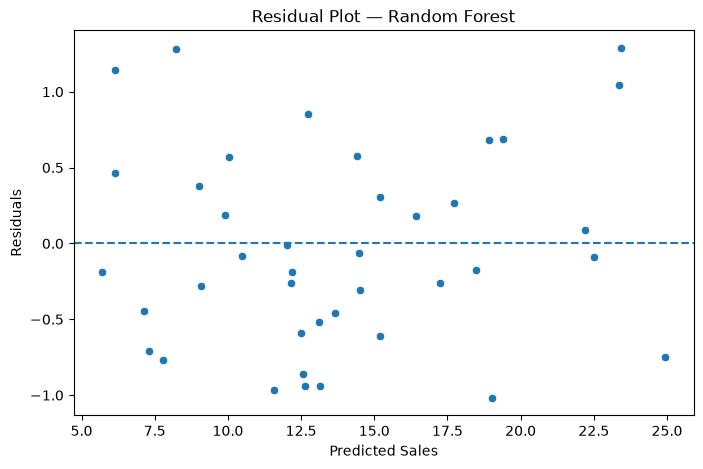

Best Model: Random Forest


In [15]:
best_model_name = results.iloc[0]["Model"]
best_model = models[best_model_name]
best_predictions = best_model.predict(X_test)

residuals = y_test - best_predictions

plt.figure(figsize=(8, 5))
sns.scatterplot(x=best_predictions, y=residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title(f"Residual Plot — {best_model_name}")
plt.show()

print("Best Model:", best_model_name)

## 15. Feature Impact
For Random Forest, feature importance shows the contribution of each feature. For a linear model, absolute coefficients are used.

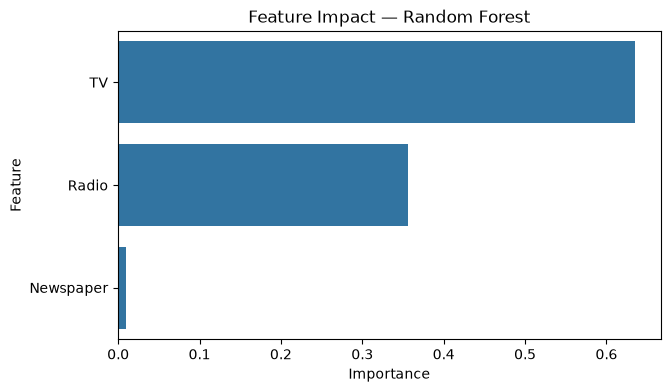

Most influential advertising channel: TV


In [16]:
if best_model_name == "Random Forest":
    importance = pd.Series(
        best_model.feature_importances_,
        index=selected_features
    )
else:
    estimator = best_model.named_steps["ridge"] if best_model_name == "Ridge Regression" else best_model
    importance = pd.Series(
        np.abs(estimator.coef_),
        index=selected_features
    )

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importance.values, y=importance.index)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Feature Impact — {best_model_name}")
plt.show()

print("Most influential advertising channel:", importance.index[0])

## 16. Select the Best Model
The best model is selected using the highest test-set R² score.

In [17]:
best_row = results.iloc[0]

print("Best Model :", best_row["Model"])
print("R² Score   :", round(best_row["R2 Score"], 4))
print("MAE        :", round(best_row["MAE"], 4))
print("RMSE       :", round(best_row["RMSE"], 4))

Best Model : Random Forest
R² Score   : 0.9847
MAE        : 0.537
RMSE       : 0.6439


## 17. Final Prediction
Use the selected model to predict sales for a new advertising budget.

In [18]:
new_ad_budget = pd.DataFrame({
    "TV": [200],
    "Radio": [40],
    "Newspaper": [30]
})

new_ad_budget = new_ad_budget[selected_features]

predicted_sales = best_model.predict(new_ad_budget)[0]

print("Predicted Sales:", round(predicted_sales, 2))

Predicted Sales: 20.75


## 18. Conclusion

The project cleaned the advertising dataset, removed the non-predictive record ID, analyzed relationships between advertising channels and sales, handled extreme observations, selected relevant features, and compared Linear Regression, Ridge Regression, and Random Forest.

The final model is selected using **R²**, while **MAE and RMSE** are also reported. Feature-impact analysis identifies which advertising channel contributes most strongly to the prediction.

This workflow provides a compact end-to-end regression pipeline suitable for the OIBSIP Data Science Task 5.